In [9]:
import zipfile

with zipfile.ZipFile("archive (1).zip") as z:
    print(z.namelist())

['predictive_maintenance_dataset.csv']


In [10]:
import pandas as pd
import zipfile

with zipfile.ZipFile("archive (1).zip") as z:
    with z.open("predictive_maintenance_dataset.csv") as f:
        df = pd.read_csv(f)

df.head()

,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
0,1/1/2015,S1F01085,0,215630672,55,0,52,6,407438,0,0,7
1,1/1/2015,S1F0166B,0,61370680,0,3,0,6,403174,0,0,0
2,1/1/2015,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0
3,1/1/2015,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0
4,1/1/2015,S1F01R2B,0,135970480,0,0,0,15,313173,0,0,3


In [11]:
df.shape

(124494, 12)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124494 entries, 0 to 124493
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   date     124494 non-null  object
 1   device   124494 non-null  object
 2   failure  124494 non-null  int64 
 3   metric1  124494 non-null  int64 
 4   metric2  124494 non-null  int64 
 5   metric3  124494 non-null  int64 
 6   metric4  124494 non-null  int64 
 7   metric5  124494 non-null  int64 
 8   metric6  124494 non-null  int64 
 9   metric7  124494 non-null  int64 
 10  metric8  124494 non-null  int64 
 11  metric9  124494 non-null  int64 
dtypes: int64(10), object(2)
memory usage: 11.4+ MB


In [13]:
df.columns

Index(['date', 'device', 'failure', 'metric1', 'metric2', 'metric3', 'metric4',
       'metric5', 'metric6', 'metric7', 'metric8', 'metric9'],
      dtype='object')

In [14]:
df["failure"].value_counts()

failure
0    124388
1       106
Name: count, dtype: int64

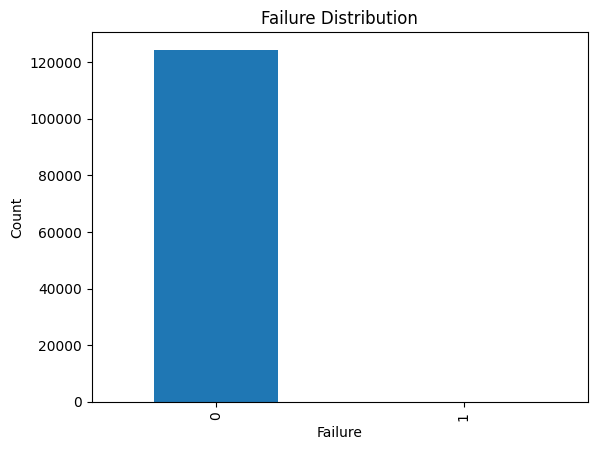

In [15]:
import matplotlib.pyplot as plt

df["failure"].value_counts().plot(kind="bar")

plt.title("Failure Distribution")
plt.xlabel("Failure")
plt.ylabel("Count")
plt.show()

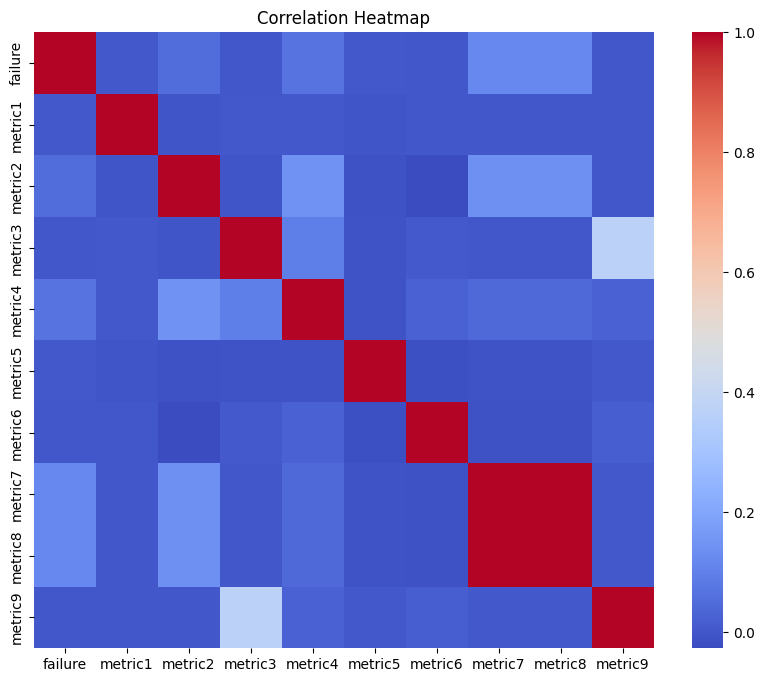

In [17]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=["date", "device", "failure"])
y = df["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pred = rf.predict(X_test)
pred_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, pred_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24878
           1       0.00      0.00      0.00        21

    accuracy                           1.00     24899
   macro avg       0.50      0.50      0.50     24899
weighted avg       1.00      1.00      1.00     24899

ROC-AUC: 0.681817746794835


In [20]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importance

,feature,importance
3,metric4,0.205208
5,metric6,0.180166
1,metric2,0.166760
0,metric1,0.153578
7,metric8,0.091945
4,metric5,0.083412
6,metric7,0.076064
8,metric9,0.029235
2,metric3,0.013631


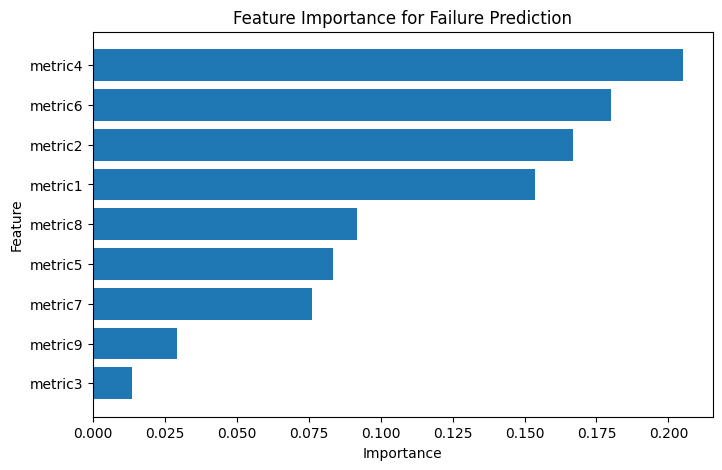

In [21]:
plt.figure(figsize=(8, 5))
plt.barh(importance["feature"][::-1], importance["importance"][::-1])
plt.title("Feature Importance for Failure Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [22]:
from sklearn.metrics import classification_report, roc_auc_score

pred = rf.predict(X_test)
pred_proba = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, pred_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24878
           1       0.00      0.00      0.00        21

    accuracy                           1.00     24899
   macro avg       0.50      0.50      0.50     24899
weighted avg       1.00      1.00      1.00     24899

ROC-AUC: 0.681817746794835


In [23]:
from imblearn.over_sampling import SMOTE

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())
print()
print(y_train_smote.value_counts())

failure
0    99510
1       85
Name: count, dtype: int64

failure
0    99510
1    99510
Name: count, dtype: int64


/Users/hwayoungshin/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [25]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

print("trained")

trained


In [26]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

pred_smote = rf_smote.predict(X_test)

pred_proba_smote = rf_smote.predict_proba(X_test)[:,1]

print(classification_report(y_test, pred_smote))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        pred_proba_smote
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24878
           1       0.09      0.14      0.11        21

    accuracy                           1.00     24899
   macro avg       0.54      0.57      0.55     24899
weighted avg       1.00      1.00      1.00     24899

ROC-AUC: 0.8223597824048021


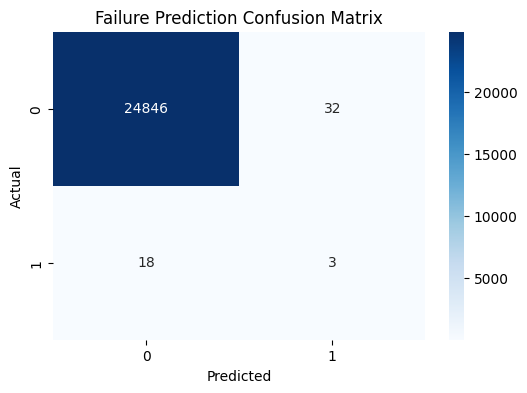

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred_smote)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Failure Prediction Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

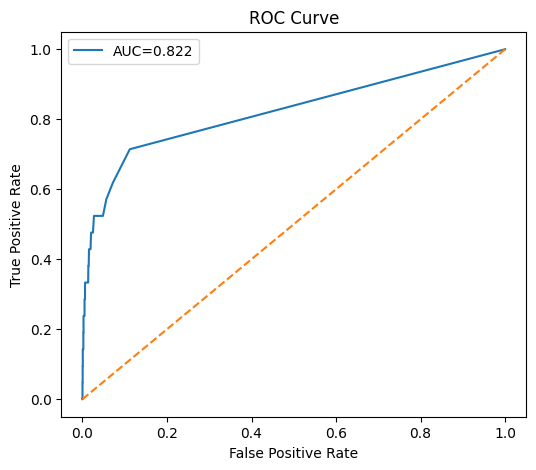

In [28]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    pred_proba_smote
)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr,
         label=f"AUC={roc_auc_score(y_test,pred_proba_smote):.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

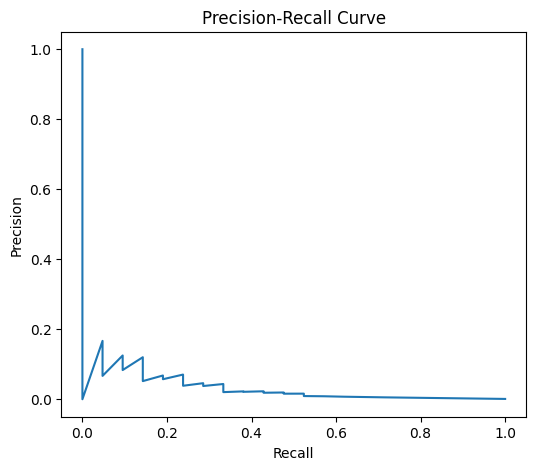

In [29]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    pred_proba_smote
)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [30]:
thresholds = [0.1,0.2,0.3,0.4,0.5]

for t in thresholds:

    pred_custom = (
        pred_proba_smote > t
    ).astype(int)

    print(f"\nThreshold = {t}")

    print(
        classification_report(
            y_test,
            pred_custom
        )
    )


Threshold = 0.1
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     24878
           1       0.03      0.33      0.05        21

    accuracy                           0.99     24899
   macro avg       0.51      0.66      0.52     24899
weighted avg       1.00      0.99      0.99     24899


Threshold = 0.2
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     24878
           1       0.04      0.29      0.07        21

    accuracy                           0.99     24899
   macro avg       0.52      0.64      0.54     24899
weighted avg       1.00      0.99      1.00     24899


Threshold = 0.3
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24878
           1       0.06      0.24      0.10        21

    accuracy                           1.00     24899
   macro avg       0.53      0.62      0.55     24899
weighted avg       1.00